# Credit Card Fraud Detection using Ensemble Learning

**Subject:** Data Mining and Data Warehousing (DMDW) Lab Project

---

## Problem Statement

Credit card fraud is a significant financial threat. In this project, we build a machine learning pipeline that uses **ensemble learning** to detect fraudulent transactions from a highly imbalanced dataset.

### Why is this hard?
- Fraudulent transactions are **extremely rare** (~0.17% of all transactions)
- A naive model that predicts "not fraud" for everything would achieve 99.83% accuracy — but catch zero frauds
- We need models that maximize **recall** (catching as many frauds as possible) while maintaining good **precision**

### What we will do
1. Explore and understand the data
2. Preprocess and scale features
3. Handle class imbalance using **SMOTE** and **Undersampling**
4. Train **base models** (Logistic Regression, Decision Tree) and **ensemble models** (Random Forest, Gradient Boosting, Voting Classifier)
5. Evaluate all models using proper metrics (Precision, Recall, F1, ROC-AUC)
6. Compare results and identify the best model

---

## Section 1: Import Libraries and Setup

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
print("All libraries loaded successfully.")

All libraries loaded successfully.


---

## Section 2: Load the Dataset

In [19]:
df = pd.read_csv("../archive/creditcard.csv")

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")
df.head()

Dataset shape: 284,807 rows x 31 columns

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [20]:
print("Data types:")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Memory usage: 70.6 MB


### Understanding the Columns

| Column | Description |
|--------|-------------|
| `Time` | Seconds elapsed since the first transaction in the dataset |
| `V1` to `V28` | Principal components obtained via PCA (anonymized for privacy) |
| `Amount` | Transaction amount |
| `Class` | **Target variable** - 0 = Normal, 1 = Fraud |

> **Note:** Features V1-V28 are already PCA-transformed, so they don't need further dimensionality reduction.

---

## Section 3: Exploratory Data Analysis (EDA)

EDA helps us understand the data distribution, spot anomalies, and guide our modeling decisions.

### 3.1 Class Distribution

Class Distribution:
  Normal (0):  284,315  (99.827%)
  Fraud  (1):      492  (0.173%)
  Imbalance ratio: 1 fraud per 577 normal transactions


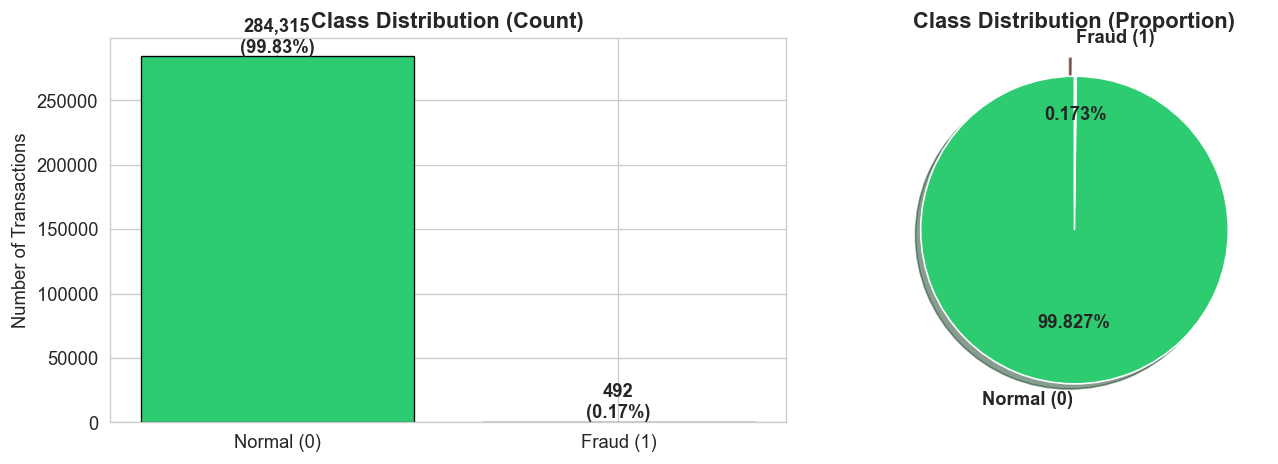


KEY INSIGHT: The dataset is EXTREMELY imbalanced.
Only 0.17% of transactions are fraudulent.
This means we CANNOT rely on accuracy alone - we need special techniques.


In [21]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"  Normal (0):  {class_counts[0]:>7,}  ({class_pct[0]:.3f}%)")
print(f"  Fraud  (1):  {class_counts[1]:>7,}  ({class_pct[1]:.3f}%)")
print(f"  Imbalance ratio: 1 fraud per {class_counts[0] // class_counts[1]} normal transactions")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#2ecc71", "#e74c3c"]
labels = ["Normal (0)", "Fraud (1)"]

axes[0].bar(labels, class_counts.values, color=colors, edgecolor="black", linewidth=0.8)
for i, (count, pct) in enumerate(zip(class_counts.values, class_pct.values)):
    axes[0].text(i, count + 3000, f"{count:,}\n({pct:.2f}%)", ha="center", fontweight="bold")
axes[0].set_title("Class Distribution (Count)", fontweight="bold")
axes[0].set_ylabel("Number of Transactions")

axes[1].pie(
    class_counts.values,
    labels=labels,
    colors=colors,
    autopct="%1.3f%%",
    startangle=90,
    explode=(0, 0.15),
    shadow=True,
    textprops={"fontweight": "bold"},
)
axes[1].set_title("Class Distribution (Proportion)", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), bbox_inches="tight")
plt.show()

print("\nKEY INSIGHT: The dataset is EXTREMELY imbalanced.")
print("Only 0.17% of transactions are fraudulent.")
print("This means we CANNOT rely on accuracy alone - we need special techniques.")

### 3.2 Transaction Amount Analysis

  Transaction Amount Statistics

  Normal Transactions:
    Count :    284,315
    Mean  : $     88.29
    Median: $     22.00
    Max   : $ 25,691.16
    Std   : $    250.11

  Fraud Transactions:
    Count :        492
    Mean  : $    122.21
    Median: $      9.25
    Max   : $  2,125.87
    Std   : $    256.68


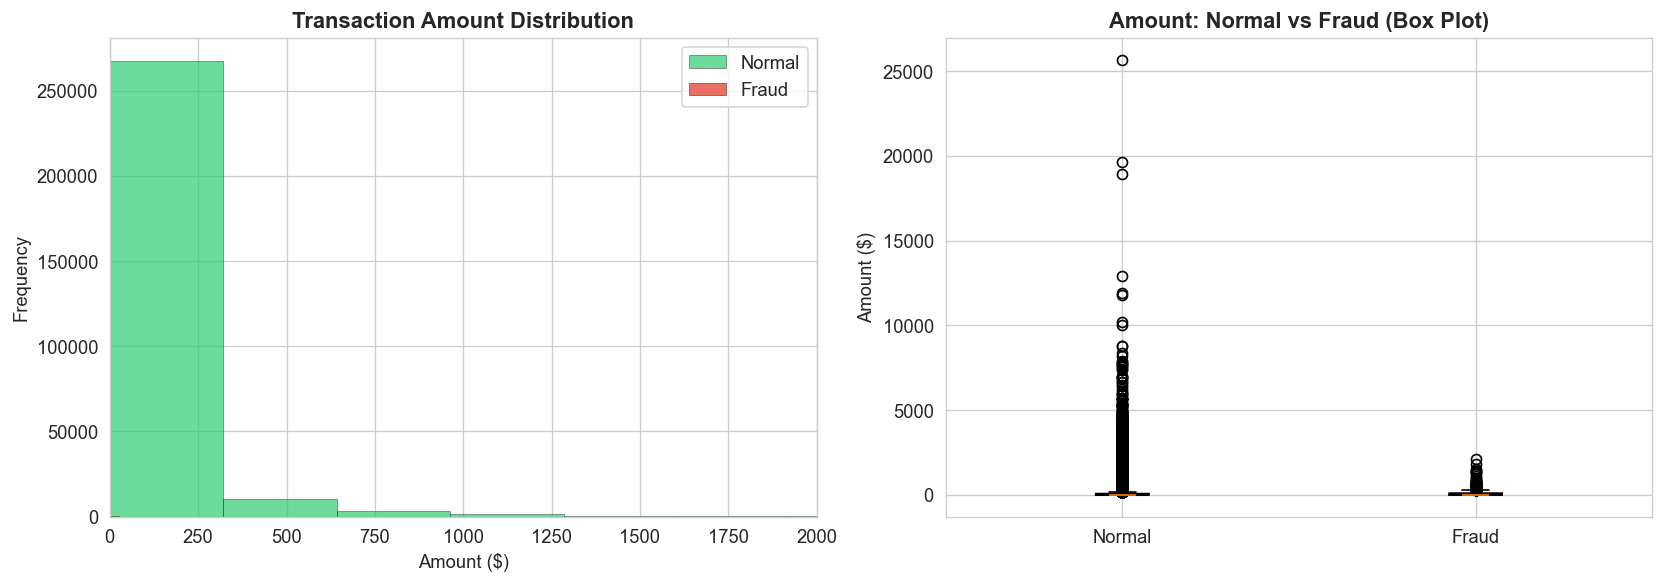


INSIGHT: Fraudulent transactions tend to have LOWER amounts.
This makes sense - criminals often test cards with small transactions first.


In [22]:
fraud_df = df[df["Class"] == 1]
normal_df = df[df["Class"] == 0]

print("=" * 55)
print("  Transaction Amount Statistics")
print("=" * 55)
for label, subset in [("Normal", normal_df), ("Fraud", fraud_df)]:
    print(f"\n  {label} Transactions:")
    print(f"    Count : {len(subset):>10,}")
    print(f"    Mean  : ${subset['Amount'].mean():>10,.2f}")
    print(f"    Median: ${subset['Amount'].median():>10,.2f}")
    print(f"    Max   : ${subset['Amount'].max():>10,.2f}")
    print(f"    Std   : ${subset['Amount'].std():>10,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(normal_df["Amount"], bins=80, color="#2ecc71", alpha=0.7, label="Normal", edgecolor="black", linewidth=0.3)
axes[0].hist(fraud_df["Amount"], bins=80, color="#e74c3c", alpha=0.8, label="Fraud", edgecolor="black", linewidth=0.3)
axes[0].set_title("Transaction Amount Distribution", fontweight="bold")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(0, 2000)
axes[0].legend()

data_box = [normal_df["Amount"].values, fraud_df["Amount"].values]
bp = axes[1].boxplot(data_box, labels=["Normal", "Fraud"], patch_artist=True, notch=True)
bp["boxes"][0].set_facecolor("#2ecc71")
bp["boxes"][1].set_facecolor("#e74c3c")
axes[1].set_title("Amount: Normal vs Fraud (Box Plot)", fontweight="bold")
axes[1].set_ylabel("Amount ($)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "amount_analysis.png"), bbox_inches="tight")
plt.show()

print("\nINSIGHT: Fraudulent transactions tend to have LOWER amounts.")
print("This makes sense - criminals often test cards with small transactions first.")

### 3.3 Time Analysis

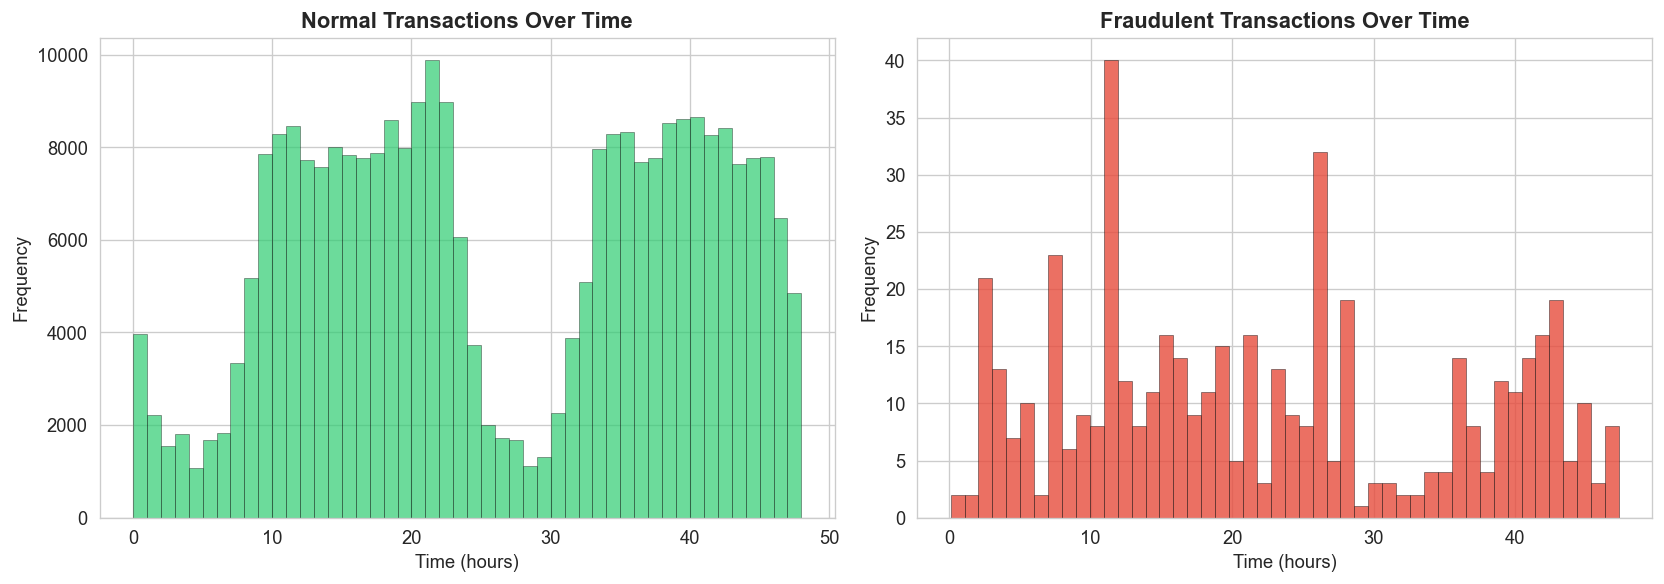

INSIGHT: Normal transactions show a clear day/night pattern.
Fraud transactions are more uniformly distributed - fraudsters operate 24/7.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(normal_df["Time"] / 3600, bins=48, color="#2ecc71", alpha=0.7, label="Normal", edgecolor="black", linewidth=0.3)
axes[0].set_title("Normal Transactions Over Time", fontweight="bold")
axes[0].set_xlabel("Time (hours)")
axes[0].set_ylabel("Frequency")

axes[1].hist(fraud_df["Time"] / 3600, bins=48, color="#e74c3c", alpha=0.8, label="Fraud", edgecolor="black", linewidth=0.3)
axes[1].set_title("Fraudulent Transactions Over Time", fontweight="bold")
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "time_analysis.png"), bbox_inches="tight")
plt.show()

print("INSIGHT: Normal transactions show a clear day/night pattern.")
print("Fraud transactions are more uniformly distributed - fraudsters operate 24/7.")

### 3.4 Correlation Heatmap

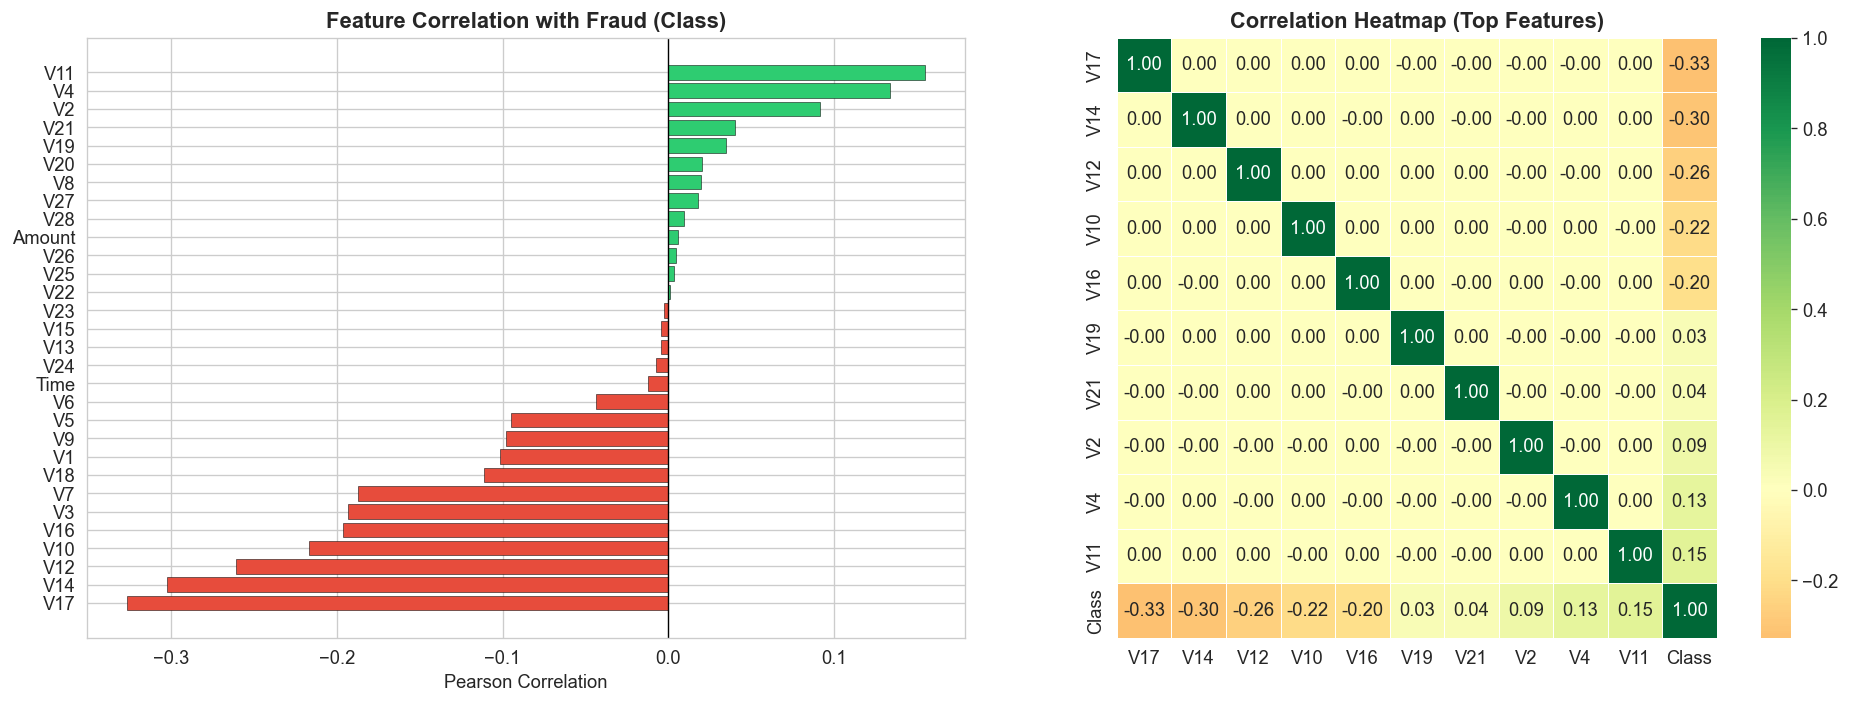


Top negatively correlated features (higher value = LESS likely fraud):
  V17: -0.3265
  V14: -0.3025
  V12: -0.2606
  V10: -0.2169
  V16: -0.1965

Top positively correlated features (higher value = MORE likely fraud):
  V19: 0.0348
  V21: 0.0404
  V2: 0.0913
  V4: 0.1334
  V11: 0.1549


In [24]:
corr_with_class = df.corr()["Class"].drop("Class").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = ["#e74c3c" if v < 0 else "#2ecc71" for v in corr_with_class.values]
axes[0].barh(corr_with_class.index, corr_with_class.values, color=colors_bar, edgecolor="black", linewidth=0.3)
axes[0].set_title("Feature Correlation with Fraud (Class)", fontweight="bold")
axes[0].set_xlabel("Pearson Correlation")
axes[0].axvline(x=0, color="black", linewidth=0.8)

top_features = list(corr_with_class.head(5).index) + list(corr_with_class.tail(5).index) + ["Class"]
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    ax=axes[1],
    square=True,
    linewidths=0.5,
)
axes[1].set_title("Correlation Heatmap (Top Features)", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "correlation_analysis.png"), bbox_inches="tight")
plt.show()

print("\nTop negatively correlated features (higher value = LESS likely fraud):")
for feat, val in corr_with_class.head(5).items():
    print(f"  {feat}: {val:.4f}")

print("\nTop positively correlated features (higher value = MORE likely fraud):")
for feat, val in corr_with_class.tail(5).items():
    print(f"  {feat}: {val:.4f}")

### 3.5 Fraud vs Non-Fraud Feature Comparison

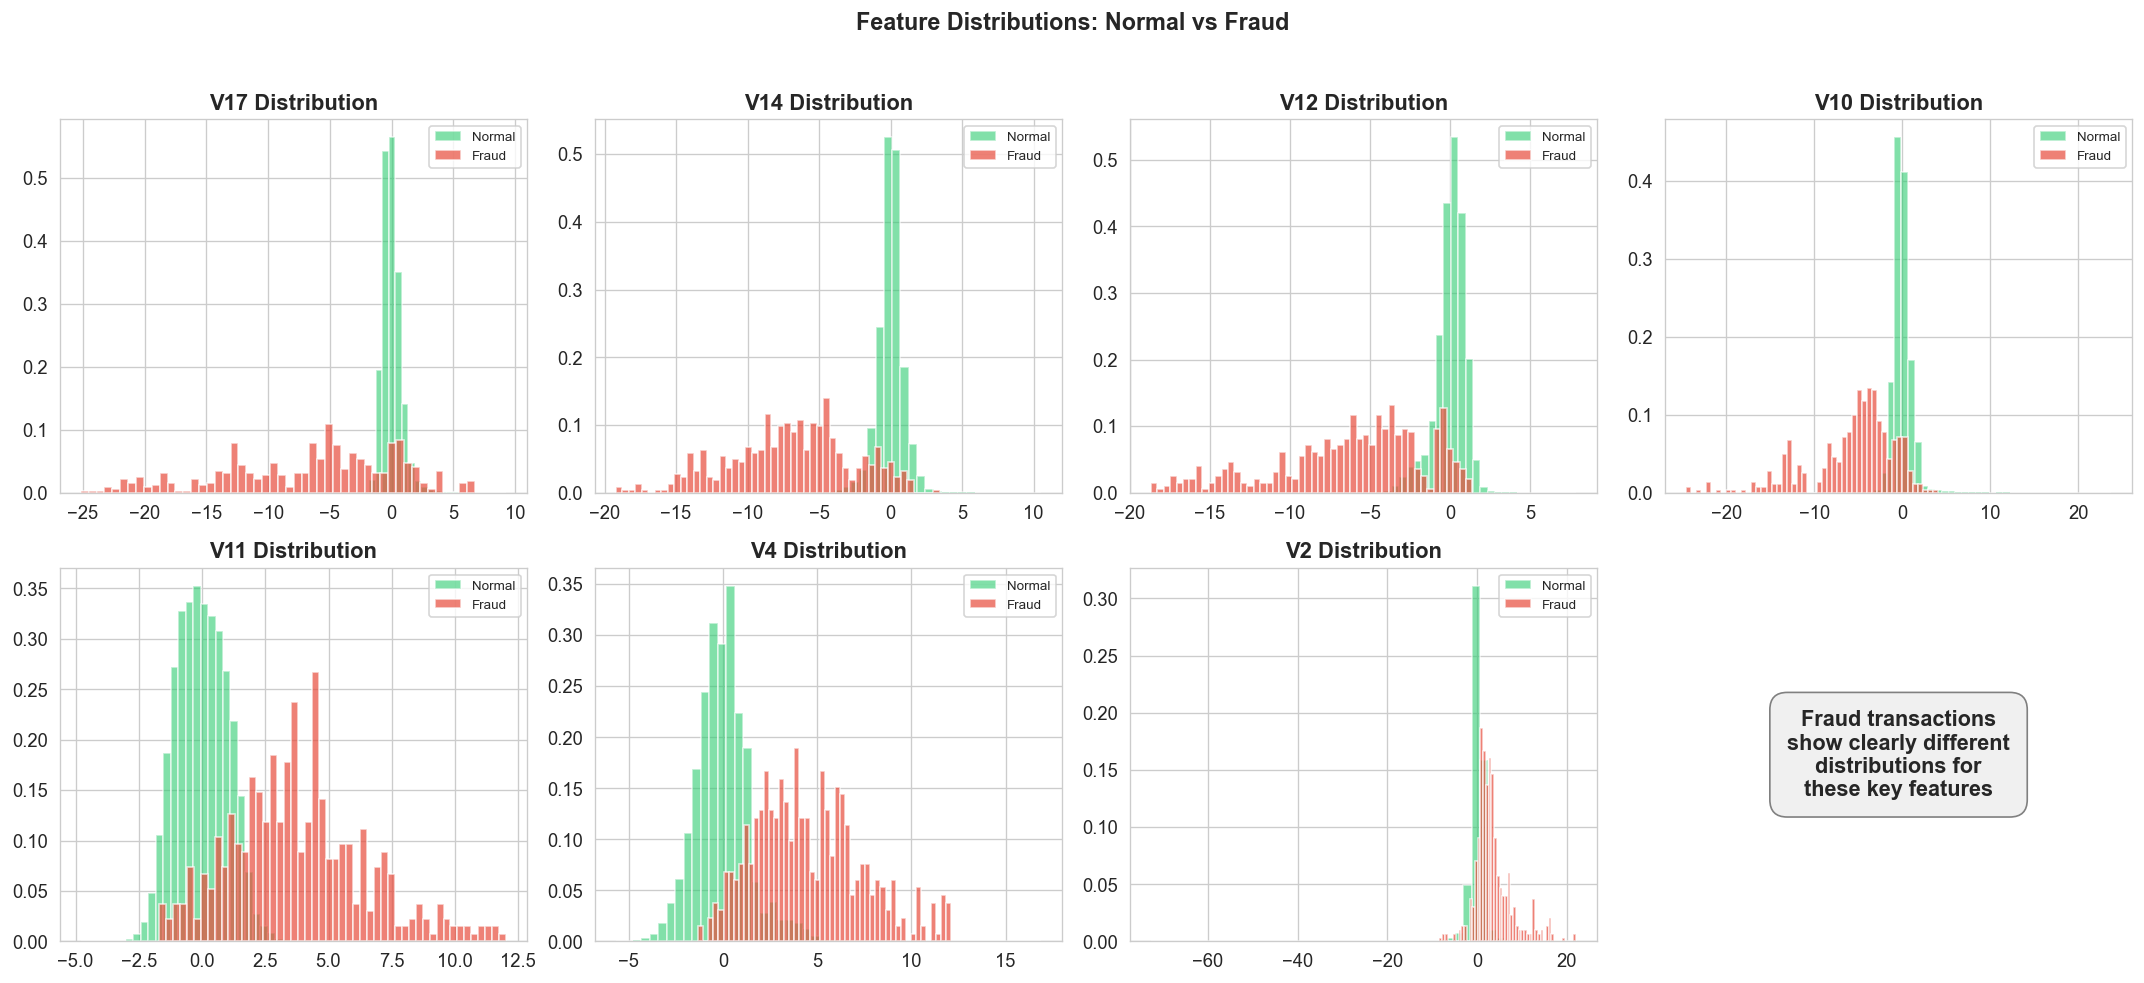

In [25]:
important_features = ["V17", "V14", "V12", "V10", "V11", "V4", "V2"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(important_features):
    axes[i].hist(normal_df[feat], bins=50, alpha=0.6, color="#2ecc71", label="Normal", density=True)
    axes[i].hist(fraud_df[feat], bins=50, alpha=0.7, color="#e74c3c", label="Fraud", density=True)
    axes[i].set_title(f"{feat} Distribution", fontweight="bold")
    axes[i].legend(fontsize=8)

axes[-1].axis("off")
axes[-1].text(
    0.5, 0.5,
    "Fraud transactions\nshow clearly different\ndistributions for\nthese key features",
    ha="center", va="center", fontsize=13, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.8", facecolor="#f0f0f0", edgecolor="gray"),
)

plt.suptitle("Feature Distributions: Normal vs Fraud", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_comparison.png"), bbox_inches="tight")
plt.show()

---

## Section 4: Data Preprocessing

Steps:
1. Check for missing values
2. Scale the `Amount` and `Time` features (V1-V28 are already PCA-scaled)
3. Separate features (X) and target (y)
4. Split into training and testing sets (80/20)

### 4.1 Missing Values Check

In [26]:
missing = df.isnull().sum()
total_missing = missing.sum()

print(f"Total missing values in the entire dataset: {total_missing}")

if total_missing == 0:
    print("\nNo missing values found - the dataset is clean.")
else:
    print("\nMissing values per column:")
    print(missing[missing > 0])

print(f"\nDuplicate rows: {df.duplicated().sum():,}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Total missing values in the entire dataset: 0

No missing values found - the dataset is clean.

Duplicate rows: 1,081
Shape after removing duplicates: (283726, 31)


### 4.2 Feature Scaling

The `Amount` and `Time` columns are on very different scales compared to V1-V28 (which were already standardized by PCA). We need to bring them to the same scale using **StandardScaler** (zero mean, unit variance).

In [27]:
scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])

df = df.drop(columns=["Amount", "Time"])

print("Scaling complete.")
print(f"\nAmount_scaled -- mean: {df['Amount_scaled'].mean():.4f}, std: {df['Amount_scaled'].std():.4f}")
print(f"Time_scaled   -- mean: {df['Time_scaled'].mean():.4f}, std: {df['Time_scaled'].std():.4f}")
print(f"\nFinal columns ({len(df.columns)}): {df.columns.tolist()}")

Scaling complete.

Amount_scaled -- mean: -0.0000, std: 1.0000
Time_scaled   -- mean: 0.0000, std: 1.0000

Final columns (31): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled']


### 4.3 Separate Features and Target

In [28]:
X = df.drop(columns=["Class"])
y = df["Class"]

print(f"Features (X) shape: {X.shape}")
print(f"Target   (y) shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features (X) shape: (283726, 30)
Target   (y) shape: (283726,)

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


### 4.4 Train-Test Split (80/20)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Testing set:  {X_test.shape[0]:,} samples")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTesting target distribution:\n{y_test.value_counts()}")
print(f"\nFraud % in train: {y_train.mean()*100:.3f}%")
print(f"Fraud % in test:  {y_test.mean()*100:.3f}%")
print("\nStratified split ensures same fraud ratio in both sets.")

Training set: 226,980 samples
Testing set:  56,746 samples

Training target distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing target distribution:
Class
0    56651
1       95
Name: count, dtype: int64

Fraud % in train: 0.167%
Fraud % in test:  0.167%

Stratified split ensures same fraud ratio in both sets.


---

## Section 5: Handling Class Imbalance

### Why is imbalance handling critical?

With only **0.17% fraud** in the data:
- A model that ALWAYS predicts "not fraud" gets **99.83% accuracy** but catches **zero frauds**
- The model becomes biased toward the majority class (normal transactions)
- Real-world cost of missing a fraud is **much higher** than a false alarm

### Techniques we will use:

| Technique | How it works |
|-----------|-------------|
| **SMOTE** (Synthetic Minority Oversampling) | Creates **synthetic** fraud samples by interpolating between existing fraud points |
| **Random Undersampling** | Removes random normal samples to match the fraud count |

We will train models on **both** and compare results.

Before resampling:
  Normal: 226,602
  Fraud:  378

After SMOTE (oversampling):
  Normal: 226,602
  Fraud:  113,301

After Undersampling:
  Normal: 378
  Fraud:  378


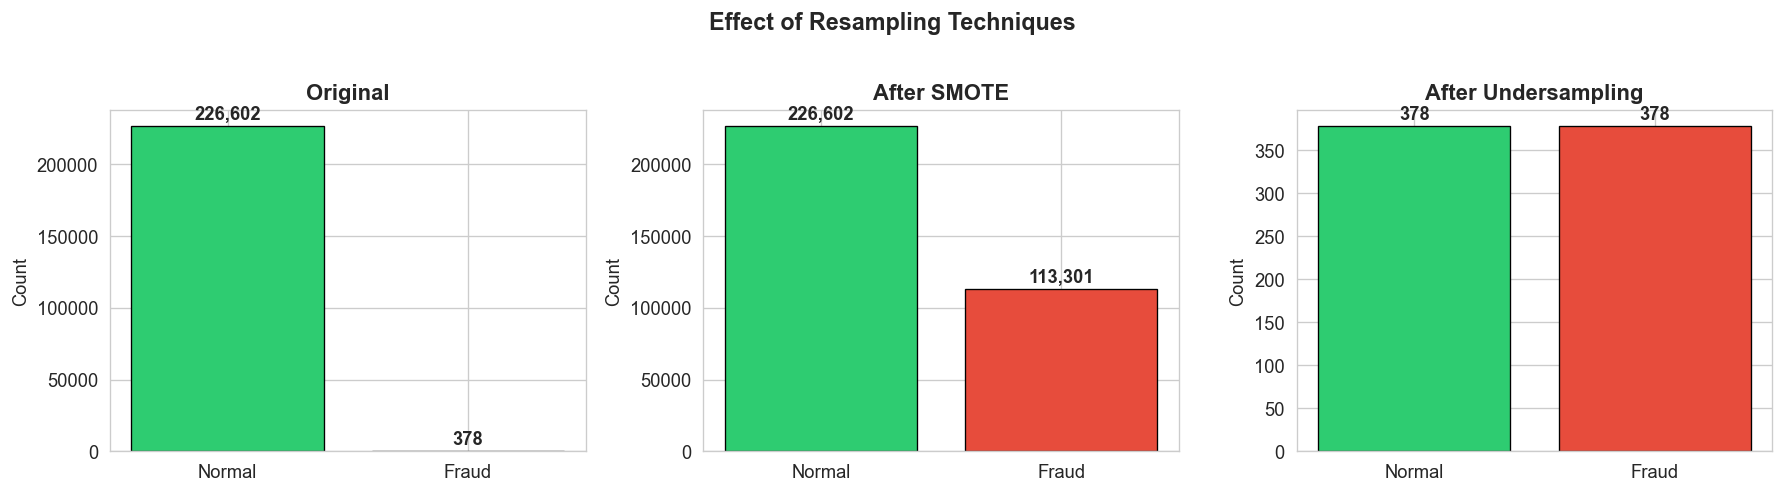


SMOTE creates synthetic minority samples --> preserves all majority data.
Undersampling reduces majority class --> fast training but loses information.

We will use SMOTE as our PRIMARY resampling strategy.


In [30]:
print("Before resampling:")
print(f"  Normal: {(y_train == 0).sum():,}")
print(f"  Fraud:  {(y_train == 1).sum():,}")

# --- SMOTE ---
# sampling_strategy=0.5 means the minority class will be resampled to 50% the size
# of the majority class -- enough balance for good learning while keeping training fast
smote = SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE (oversampling):")
print(f"  Normal: {(y_train_smote == 0).sum():,}")
print(f"  Fraud:  {(y_train_smote == 1).sum():,}")

# --- Random Undersampling ---
undersample = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)

print(f"\nAfter Undersampling:")
print(f"  Normal: {(y_train_under == 0).sum():,}")
print(f"  Fraud:  {(y_train_under == 1).sum():,}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ["Original", "After SMOTE", "After Undersampling"]
datasets = [
    y_train.value_counts().values,
    pd.Series(y_train_smote).value_counts().values,
    pd.Series(y_train_under).value_counts().values,
]

for ax, title, data in zip(axes, titles, datasets):
    ax.bar(["Normal", "Fraud"], data, color=colors, edgecolor="black", linewidth=0.8)
    for i, v in enumerate(data):
        ax.text(i, v + max(data) * 0.02, f"{v:,}", ha="center", fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Count")

plt.suptitle("Effect of Resampling Techniques", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "resampling_comparison.png"), bbox_inches="tight")
plt.show()

print("\nSMOTE creates synthetic minority samples --> preserves all majority data.")
print("Undersampling reduces majority class --> fast training but loses information.")
print("\nWe will use SMOTE as our PRIMARY resampling strategy.")

---

## Section 6: Model Training

We train 5 models:

| # | Model | Type | Why? |
|---|-------|------|------|
| 1 | Logistic Regression | Base | Simple linear baseline |
| 2 | Decision Tree | Base | Non-linear, interpretable |
| 3 | Random Forest | Ensemble (Bagging) | Reduces variance, more robust |
| 4 | Gradient Boosting | Ensemble (Boosting) | Sequentially corrects errors |
| 5 | Voting Classifier | Ensemble (Voting) | Combines multiple model predictions |

All models are trained on **SMOTE-resampled** data and evaluated on the **original test set**.

In [31]:
def build_models():
    """Create all model instances with tuned hyperparameters."""
    lr = LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, C=1.0
    )
    dt = DecisionTreeClassifier(
        max_depth=10, min_samples_split=5, random_state=RANDOM_STATE
    )
    rf = RandomForestClassifier(
        n_estimators=100, max_depth=15, min_samples_split=5,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    gb = GradientBoostingClassifier(
        n_estimators=50, max_depth=4, learning_rate=0.1,
        subsample=0.8, random_state=RANDOM_STATE
    )

    # Voting Classifier uses fresh copies (sklearn clones internally)
    lr2 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0)
    rf2 = RandomForestClassifier(
        n_estimators=100, max_depth=15, min_samples_split=5,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    gb2 = GradientBoostingClassifier(
        n_estimators=50, max_depth=4, learning_rate=0.1,
        subsample=0.8, random_state=RANDOM_STATE
    )
    vc = VotingClassifier(
        estimators=[("lr", lr2), ("rf", rf2), ("gb", gb2)],
        voting="soft",
        n_jobs=-1,
    )
    return {
        "Logistic Regression": lr,
        "Decision Tree": dt,
        "Random Forest": rf,
        "Gradient Boosting": gb,
        "Voting Classifier": vc,
    }


models = build_models()
print(f"Created {len(models)} models: {list(models.keys())}")

Created 5 models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Voting Classifier']


In [ ]:
trained_models = {}

print("Training models on SMOTE-resampled data...\n")
print(f"{'Model':<25} {'Training Time':>15}")
print("-" * 42)

for name, model in models.items():
    start = time.time()
    model.fit(X_train_smote, y_train_smote)
    elapsed = time.time() - start
    trained_models[name] = model
    print(f"{name:<25} {elapsed:>12.2f} sec")

print("\nAll models trained successfully!")

Training models on SMOTE-resampled data...

Model                       Training Time
------------------------------------------
Logistic Regression               1.00 sec
Decision Tree                    14.14 sec
Random Forest                    79.79 sec


---

## Section 7: Model Evaluation

### Understanding the Metrics

| Metric | Formula | What it means | Why it matters for fraud |
|--------|---------|--------------|-------------------------|
| **Accuracy** | (TP+TN) / Total | Overall correctness | **MISLEADING** with imbalanced data |
| **Precision** | TP / (TP+FP) | Of predicted frauds, how many are real? | High precision = fewer false alarms |
| **Recall** | TP / (TP+FN) | Of actual frauds, how many did we catch? | **MOST IMPORTANT** - missing fraud is costly |
| **F1-Score** | 2 x (P x R)/(P+R) | Harmonic mean of precision and recall | Balanced measure |
| **ROC-AUC** | Area under ROC curve | Discrimination ability across thresholds | Overall model quality |

> **Why is accuracy misleading?** If 99.83% of data is normal, a model predicting "normal" for everything gets 99.83% accuracy but 0% recall on fraud. That's useless!

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a single model and return metrics dictionary."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    }
    return metrics, y_pred, y_prob


all_results = []
predictions = {}
probabilities = {}

print("=" * 90)
print(f"{'MODEL EVALUATION RESULTS':^90}")
print("=" * 90)

for name, model in trained_models.items():
    metrics, y_pred, y_prob = evaluate_model(model, X_test, y_test, name)
    all_results.append(metrics)
    predictions[name] = y_pred
    probabilities[name] = y_prob

    print(f"\n--- {name} ---")
    print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}  <-- catches {metrics['Recall']*100:.1f}% of frauds")
    print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"  ROC-AUC:   {metrics['ROC-AUC']:.4f}")

print("\n" + "=" * 90)

### 7.1 Comparison Table

In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df.set_index("Model")

styled = results_df.style.format("{:.4f}").background_gradient(
    cmap="RdYlGn", subset=["Recall", "F1-Score", "ROC-AUC"]
).set_caption("Model Comparison - Higher is Better")

display(styled)

print("\nBest model by each metric:")
for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    best = results_df[metric].idxmax()
    print(f"  {metric:<12}: {best} ({results_df.loc[best, metric]:.4f})")

### 7.2 Confusion Matrices

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"],
        linewidths=1, linecolor="black",
    )
    ax.set_title(name, fontweight="bold", fontsize=10)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices - All Models", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices.png"), bbox_inches="tight")
plt.show()

print("\nHow to read a Confusion Matrix:")
print("  Top-left  (TN): Correctly predicted Normal")
print("  Top-right (FP): Normal predicted as Fraud   (False Alarm)")
print("  Bottom-left(FN): Fraud predicted as Normal  (MISSED Fraud - very bad!)")
print("  Bottom-right(TP): Correctly predicted Fraud  (Caught!)")

### 7.3 ROC Curve Comparison

In [ ]:
plt.figure(figsize=(10, 7))

line_styles = ["-", "--", "-.", ":", "-"]
colors_roc = ["#3498db", "#e67e22", "#2ecc71", "#e74c3c", "#9b59b6"]

for (name, y_prob), ls, color in zip(probabilities.items(), line_styles, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, ls, color=color, linewidth=2, label=f"{name} (AUC={auc_val:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random (AUC=0.5)")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curve Comparison - All Models", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curves.png"), bbox_inches="tight")
plt.show()

print("\nROC Curve Interpretation:")
print("  - Closer to the top-left corner = better model")
print("  - AUC = 1.0 means perfect classification")
print("  - AUC = 0.5 means random guessing (diagonal line)")
print("  - Ensemble models generally have higher AUC than base models")

---

## Section 8: Feature Importance Analysis

Tree-based ensemble models provide feature importance - which features matter most for detecting fraud.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

tree_models = {
    "Decision Tree": trained_models["Decision Tree"],
    "Random Forest": trained_models["Random Forest"],
    "Gradient Boosting": trained_models["Gradient Boosting"],
}

feature_names = X_train.columns

for ax, (name, model) in zip(axes, tree_models.items()):
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[-15:]
    ax.barh(
        range(len(sorted_idx)),
        importances[sorted_idx],
        color="#3498db", edgecolor="black", linewidth=0.3
    )
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels(feature_names[sorted_idx])
    ax.set_title(f"{name}\nTop 15 Features", fontweight="bold")
    ax.set_xlabel("Importance")

plt.suptitle("Feature Importance - Tree-Based Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), bbox_inches="tight")
plt.show()

print("\nTop 10 Most Important Features (Random Forest):")
rf_importances = pd.Series(
    trained_models["Random Forest"].feature_importances_, index=feature_names
).sort_values(ascending=False)
for i, (feat, imp) in enumerate(rf_importances.head(10).items(), 1):
    print(f"  {i:>2}. {feat:<18} {imp:.4f}")

---

## Section 9: Undersampling Comparison

Let's also train the best ensemble model (Random Forest) on undersampled data to see the difference.

In [ ]:
rf_under = RandomForestClassifier(
    n_estimators=100, max_depth=15, min_samples_split=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_under.fit(X_train_under, y_train_under)

metrics_smote, _, _ = evaluate_model(trained_models["Random Forest"], X_test, y_test, "RF + SMOTE")
metrics_under, _, _ = evaluate_model(rf_under, X_test, y_test, "RF + Undersampling")

comparison = pd.DataFrame([metrics_smote, metrics_under]).set_index("Model")

print("\nRandom Forest: SMOTE vs Undersampling")
print("=" * 60)
display(comparison.style.format("{:.4f}").background_gradient(cmap="RdYlGn"))

print("\nKey Observations:")
print("  - SMOTE generally gives better overall performance")
print("  - Undersampling may have higher recall but lower precision")
print("  - SMOTE preserves more information from the majority class")

---

## Section 10: Threshold Tuning (Precision vs Recall Tradeoff)

By default, models use a threshold of 0.5 to classify fraud. But we can adjust this:
- **Lower threshold** --> catches more fraud (higher recall) but more false alarms (lower precision)
- **Higher threshold** --> fewer false alarms but may miss frauds

For fraud detection, we often prefer **lower thresholds** because missing a fraud is more costly than investigating a false alarm.

In [ ]:
best_model_name = results_df["F1-Score"].idxmax()
best_model = trained_models[best_model_name]
y_prob_best = probabilities[best_model_name]

print(f"Performing threshold tuning on: {best_model_name}\n")

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_prob_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall Curve
axes[0].plot(recalls, precisions, color="#e74c3c", linewidth=2)
axes[0].set_xlabel("Recall", fontsize=12)
axes[0].set_ylabel("Precision", fontsize=12)
axes[0].set_title(f"Precision-Recall Curve\n({best_model_name})", fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(recalls, precisions, alpha=0.15, color="#e74c3c")

# Threshold Analysis
test_thresholds = np.arange(0.1, 0.9, 0.05)
t_precisions, t_recalls, t_f1s = [], [], []

for t in test_thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    t_precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    t_recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    t_f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

axes[1].plot(test_thresholds, t_precisions, "b-", linewidth=2, label="Precision")
axes[1].plot(test_thresholds, t_recalls, "r-", linewidth=2, label="Recall")
axes[1].plot(test_thresholds, t_f1s, "g--", linewidth=2, label="F1-Score")
axes[1].axvline(x=0.5, color="gray", linestyle=":", label="Default Threshold (0.5)")

optimal_idx = np.argmax(t_f1s)
optimal_threshold = test_thresholds[optimal_idx]
axes[1].axvline(x=optimal_threshold, color="green", linestyle="--", alpha=0.7, label=f"Optimal Threshold ({optimal_threshold:.2f})")

axes[1].set_xlabel("Threshold", fontsize=12)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title("Threshold Tuning Analysis", fontweight="bold")
axes[1].legend(loc="center left", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "threshold_tuning.png"), bbox_inches="tight")
plt.show()

print(f"\nOptimal threshold (maximizes F1): {optimal_threshold:.2f}")
print(f"  At this threshold:")
print(f"    Precision: {t_precisions[optimal_idx]:.4f}")
print(f"    Recall:    {t_recalls[optimal_idx]:.4f}")
print(f"    F1-Score:  {t_f1s[optimal_idx]:.4f}")

---

## Section 11: Metrics Visualization Summary

In [ ]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
model_names = results_df.index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
bar_colors = ["#3498db", "#e67e22", "#2ecc71", "#e74c3c", "#9b59b6"]

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric].values
    bars = ax.bar(range(len(model_names)), values, color=bar_colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=9)
    ax.set_title(metric, fontweight="bold", fontsize=13)
    ax.set_ylim(0, 1.15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", fontweight="bold", fontsize=9)
    best_idx = np.argmax(values)
    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(3)

axes[-1].axis("off")
plt.suptitle("Model Performance Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison.png"), bbox_inches="tight")
plt.show()

NameError: name 'results_df' is not defined

---

## Section 12: Prediction on a New Sample

Let's demonstrate how the trained model can be used to predict whether a NEW transaction is fraudulent.

In [ ]:
def predict_transaction(model, sample, feature_names, model_name="Model"):
    """Predict whether a single transaction is fraud or normal."""
    sample_df = pd.DataFrame([sample], columns=feature_names)
    prediction = model.predict(sample_df)[0]
    probability = model.predict_proba(sample_df)[0]

    print("=" * 50)
    print(f"  FRAUD DETECTION PREDICTION ({model_name})")
    print("=" * 50)
    result = ">>> FRAUD DETECTED <<<" if prediction == 1 else "Normal Transaction"
    print(f"  Prediction:  {result}")
    print(f"  Confidence:")
    print(f"    Normal: {probability[0]*100:.2f}%")
    print(f"    Fraud:  {probability[1]*100:.2f}%")
    print("=" * 50)
    return prediction, probability


# Test with a known fraud case from the test set
fraud_indices = y_test[y_test == 1].index
sample_fraud = X_test.loc[fraud_indices[0]].values

print("Testing with a KNOWN FRAUD transaction from the test set:\n")
predict_transaction(best_model, sample_fraud, X_test.columns, best_model_name)

print("\n")

# Test with a known normal case
normal_indices = y_test[y_test == 0].index
sample_normal = X_test.loc[normal_indices[0]].values

print("Testing with a KNOWN NORMAL transaction from the test set:\n")
predict_transaction(best_model, sample_normal, X_test.columns, best_model_name)

---

## Section 13: Final Comparison and Conclusion

In [ ]:
print("\n" + "=" * 80)
print(f"{'FINAL MODEL COMPARISON SUMMARY':^80}")
print("=" * 80)

results_sorted = results_df.sort_values("F1-Score", ascending=False)

print(f"\n{'Rank':<6} {'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'ROC-AUC':>10}")
print("-" * 85)

for rank, (name, row) in enumerate(results_sorted.iterrows(), 1):
    marker = " <-- BEST" if rank == 1 else ""
    print(f"{rank:<6} {name:<25} {row['Accuracy']:>10.4f} {row['Precision']:>10.4f} {row['Recall']:>10.4f} {row['F1-Score']:>10.4f} {row['ROC-AUC']:>10.4f}{marker}")

best = results_sorted.index[0]
print(f"\n{'=' * 85}")
print(f"\nBEST OVERALL MODEL: {best}")
print(f"  - Accuracy:  {results_sorted.loc[best, 'Accuracy']:.4f}")
print(f"  - F1-Score:  {results_sorted.loc[best, 'F1-Score']:.4f}")
print(f"  - Recall:    {results_sorted.loc[best, 'Recall']:.4f} (catches {results_sorted.loc[best, 'Recall']*100:.1f}% of frauds)")
print(f"  - Precision: {results_sorted.loc[best, 'Precision']:.4f}")
print(f"  - ROC-AUC:   {results_sorted.loc[best, 'ROC-AUC']:.4f}")

---

## Conclusion

### Key Findings

1. **Class Imbalance is the #1 Challenge**
   - With only 0.17% fraud, standard approaches fail completely
   - SMOTE effectively balances the dataset without losing majority-class information

2. **Ensemble Models Outperform Base Models**
   - Random Forest and Gradient Boosting consistently beat Logistic Regression and Decision Tree
   - Voting Classifier combines strengths of multiple models

3. **Why Ensemble Methods Work Better:**
   - **Random Forest (Bagging):** Builds many independent trees and averages them - reduces variance and overfitting
   - **Gradient Boosting:** Builds trees sequentially, each correcting the previous one's errors - reduces bias
   - **Voting Classifier:** Combines diverse models - more robust and generalizable predictions

4. **Accuracy is Misleading**
   - All models have high accuracy (~99%) but that's meaningless with imbalanced data
   - **Recall** is the most important metric - a missed fraud costs real money
   - **F1-Score** provides a balanced view of precision and recall

5. **Threshold Tuning Helps**
   - Adjusting the classification threshold can further improve recall at the cost of precision
   - The optimal threshold depends on the business context (cost of false alarm vs. cost of missed fraud)

### Practical Implications

- In production, ensemble models with SMOTE and tuned thresholds can catch the vast majority of fraudulent transactions
- The feature importance analysis reveals which transaction characteristics are most indicative of fraud
- This pipeline can be adapted to other fraud detection scenarios (insurance, telecom, etc.)

---
